## Partie 1 (modélisation sous forme de graphe) :
Représenter graphiquement l’essaim dans les trois configurations de densité et pour les trois niveaux de portée.

In [15]:
import numpy as np
import math
import networkx as nx

from collections import Counter
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



# Fonction qui extrait les positions des satellites et calcule la matrice des distances.
def get_positions_and_matrix(ligne):

    N = len(ligne)  
    ids = [sat['sat_id'] for sat in ligne]


    coords = np.array([
        [float(sat['x']), float(sat['y']), float(sat['z'])]
        for sat in ligne
    ]) / 1000.0

    positions = {ids[i]: tuple(coords[i]) for i in range(N)}
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    M = np.sqrt(np.sum(diff ** 2, axis=-1))

    return positions, M, ids


# Si weighted=True, les arêtes sont pondérées par le carré de la distance (pour la partie 3)
def create_graph(positions, M, ids, portee, weighted=False):
    G = nx.Graph()
    N = len(ids)

    for i in range(N):
        G.add_node(ids[i], pos=positions[ids[i]])

    connected_indices = np.argwhere((M <= portee) & (M > 0))

    for i, j in connected_indices:
        if i < j:  
            u, v = ids[i], ids[j]
            dist = M[i, j]

            if weighted:
                G.add_edge(u, v, weight=dist ** 2)
            else:
                G.add_edge(u, v)

    return G


In [16]:
def load_topology(filename):
    """
    Charge les données satellites depuis un fichier CSV
    """
    satellites = []
    with open(filename, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            satellites.append(row)
    return satellites


import matplotlib.pyplot as plt

def plot_graph_3d_on_ax(G, positions, ax, titre):
    """
    Affiche un graphe 3D sur un axe matplotlib donné
    """

    xs = [positions[n][0] for n in G.nodes()]
    ys = [positions[n][1] for n in G.nodes()]
    zs = [positions[n][2] for n in G.nodes()]

    # Sommets
    ax.scatter(xs, ys, zs, c='blue', s=15)

    # Arêtes
    for u, v in G.edges():
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        z = [positions[u][2], positions[v][2]]
        ax.plot(x, y, z, c='gray', linewidth=0.6)

    ax.set_title(titre)
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")
    ax.set_zlabel("Z (km)")


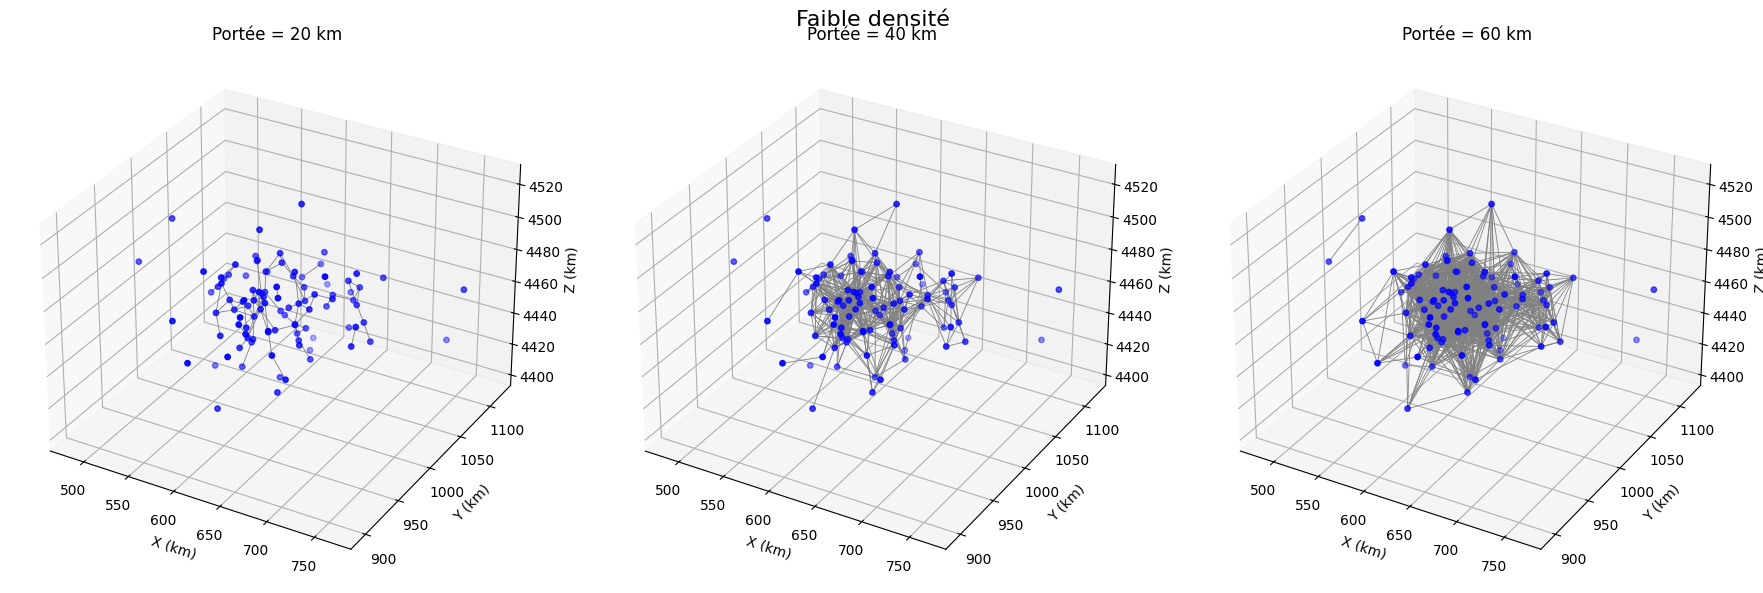

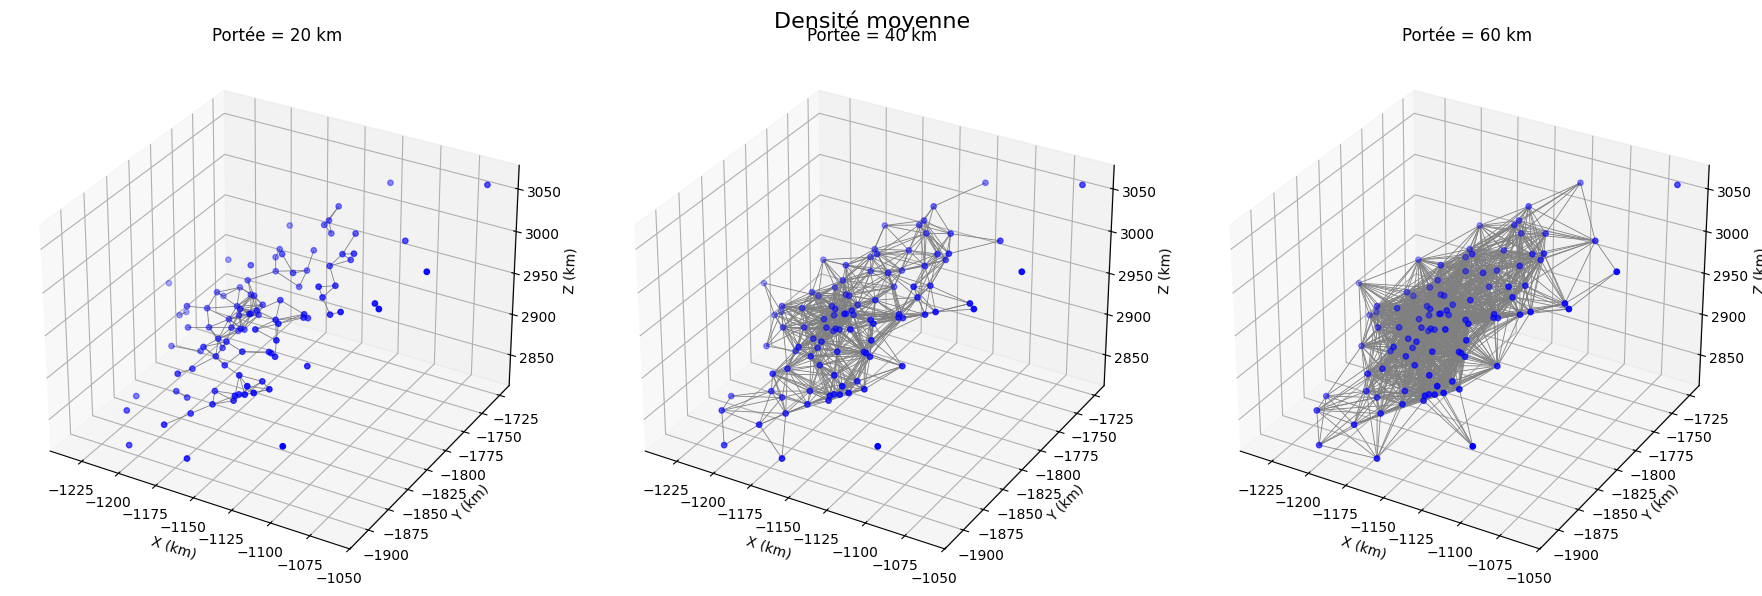

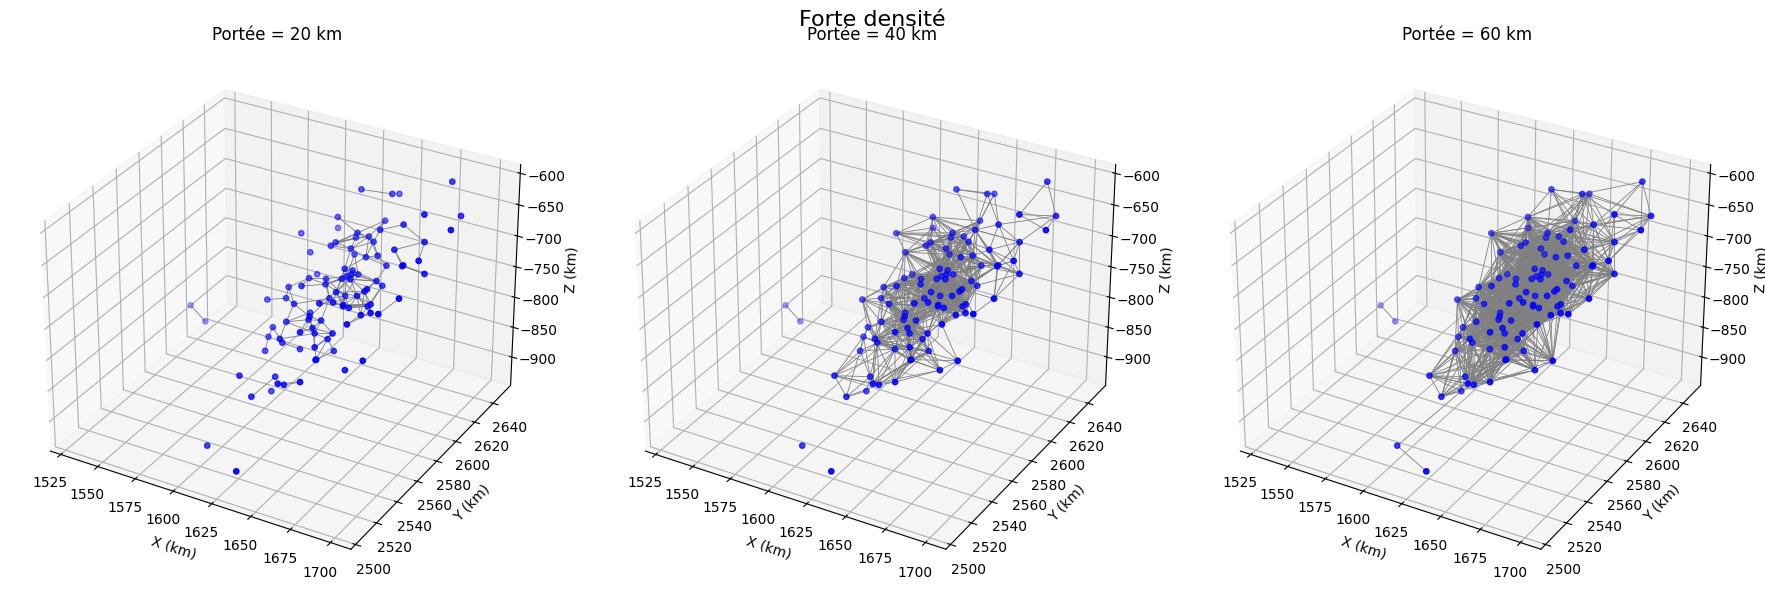

In [30]:
# Script principal 
import matplotlib.pyplot as plt

fichiers = {
    "Faible densité": "Topologies-20260107/topology_low.csv",
    "Densité moyenne": "Topologies-20260107/topology_avg.csv",
    "Forte densité": "Topologies-20260107/topology_high.csv"
}

portees = [20, 40, 60]


for label, fichier in fichiers.items():
    ligne = load_topology(fichier)
    positions, M, ids = get_positions_and_matrix(ligne)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6),
        subplot_kw={'projection': '3d'}
    )

    for j, portee in enumerate(portees):
        G = create_graph(positions, M, ids, portee, weighted=False)

        plot_graph_3d_on_ax(
            G,
            positions,
            axes[j],
            titre=f"Portée = {portee} km"
        )

    fig.suptitle(label, fontsize=16)


    plt.tight_layout()
    plt.show()


## Partie 2 (étude des graphes non valués) : 
Calculer les caractéristiques de ces graphes dans les neuf cas
distincts

In [18]:
def count_all_shortest_paths(G):
    """
    Compte le nombre total de plus courts chemins
    entre tous les couples de sommets connectés
    """
    total = 0
    nodes = list(G.nodes())

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u = nodes[i]
            v = nodes[j]

            if nx.has_path(G, u, v):
                total += len(list(nx.all_shortest_paths(G, u, v)))

    return total

def analyze_graph_characteristics(path, portee, title):
    """
    Analyse complète d'un graphe non valué :
    - Calcul des métriques
    - Préparation des distributions
    """

    ligne = load_topology(path)
    positions, M, ids = get_positions_and_matrix(ligne)

    G = create_graph(positions, M, ids, portee, weighted=False)
    degrees = [d for _, d in G.degree()]
    degree_mean = sum(degrees) / len(degrees)
    
    # Distribution du degré 
    degree_distribution = Counter(degrees)

    clustering = nx.clustering(G)
    clustering_values = list(clustering.values())
    
     # cliques maximales
    cliques = list(nx.find_cliques(G)) 
    clique_sizes = [len(c) for c in cliques]
    
    components = list(nx.connected_components(G))
    component_sizes = [len(c) for c in components]

    # Plus courts chemins
    if nx.is_connected(G):
        G_sp = G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sp = G.subgraph(largest_cc)

    lengths = dict(nx.all_pairs_shortest_path_length(G_sp))

    dist = []
    for u in lengths:
        for v in lengths[u]:
            if u < v:
                dist.append(lengths[u][v])

    total_shortest_paths = count_all_shortest_paths(G_sp)
    
    return G, degrees,degree_distribution, clustering_values, component_sizes, dist, clique_sizes


In [19]:
def analyze_all():
    fichiers = {
        "Faible densité": "Topologies-20260107/topology_low.csv",
        "Densité moyenne": "Topologies-20260107/topology_avg.csv",
        "Forte densité": "Topologies-20260107/topology_high.csv"
    }

    portees = [20, 40, 60]
    results = {}

    for label, path in fichiers.items():
        results[label] = {}
        for portee in portees:
            title = f"{label} – Portée {portee} km"
            G, deg,deg_dist, clust, comps, dist, cliques = analyze_graph_characteristics(path, portee, title)

            results[label][portee] = {
                "degree": deg,
                "degree_distribution": deg_dist,
                "clustering": clust,
                "components": comps,
                "dist": dist,
                "cliques": cliques
            }

    return results


### Distribution des degrés :

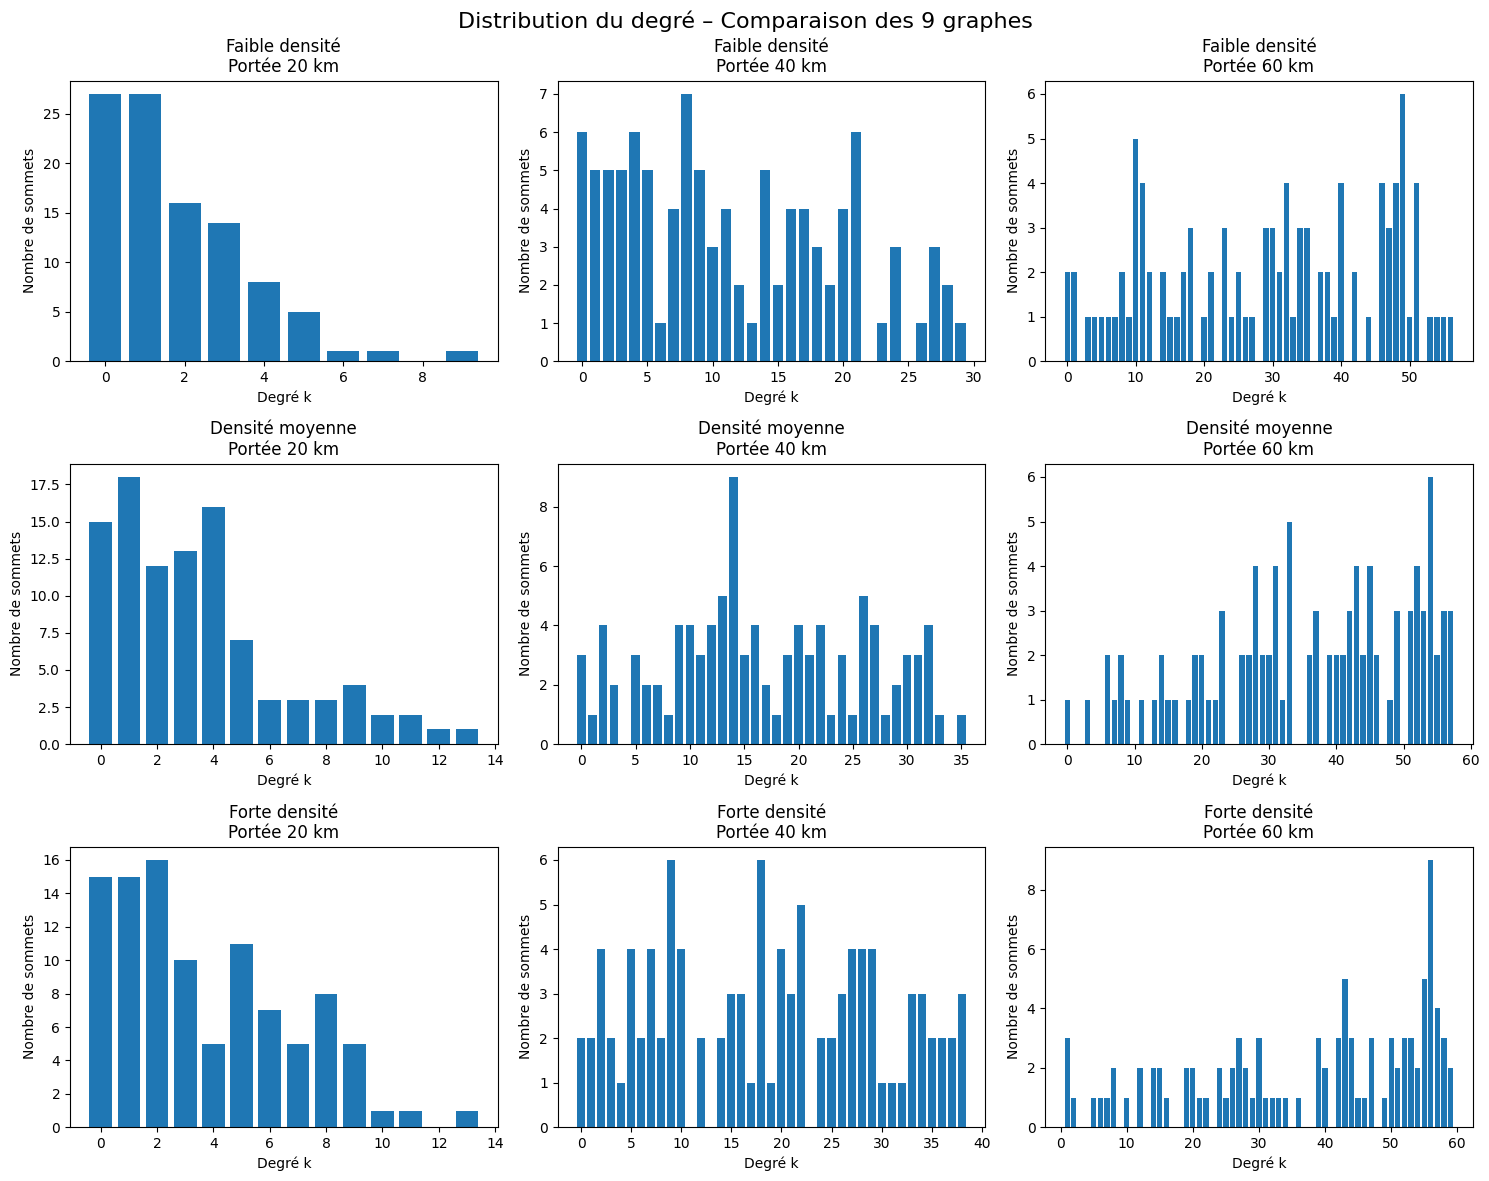

In [20]:
def plot_all_degree_distributions(results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    portees = [20, 40, 60]

    for i, (label, data) in enumerate(results.items()):
        for j, portee in enumerate(portees):
            ax = axes[i, j]
            deg_dist = data[portee]["degree_distribution"]

            ks = sorted(deg_dist.keys())
            values = [deg_dist[k] for k in ks]

            ax.bar(ks, values)
            ax.set_title(f"{label}\nPortée {portee} km")
            ax.set_xlabel("Degré k")
            ax.set_ylabel("Nombre de sommets")

    fig.suptitle("Distribution du degré – Comparaison des 9 graphes", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_all_degree_distributions(analyze_all())

### Distribution des dégrés de Clustering

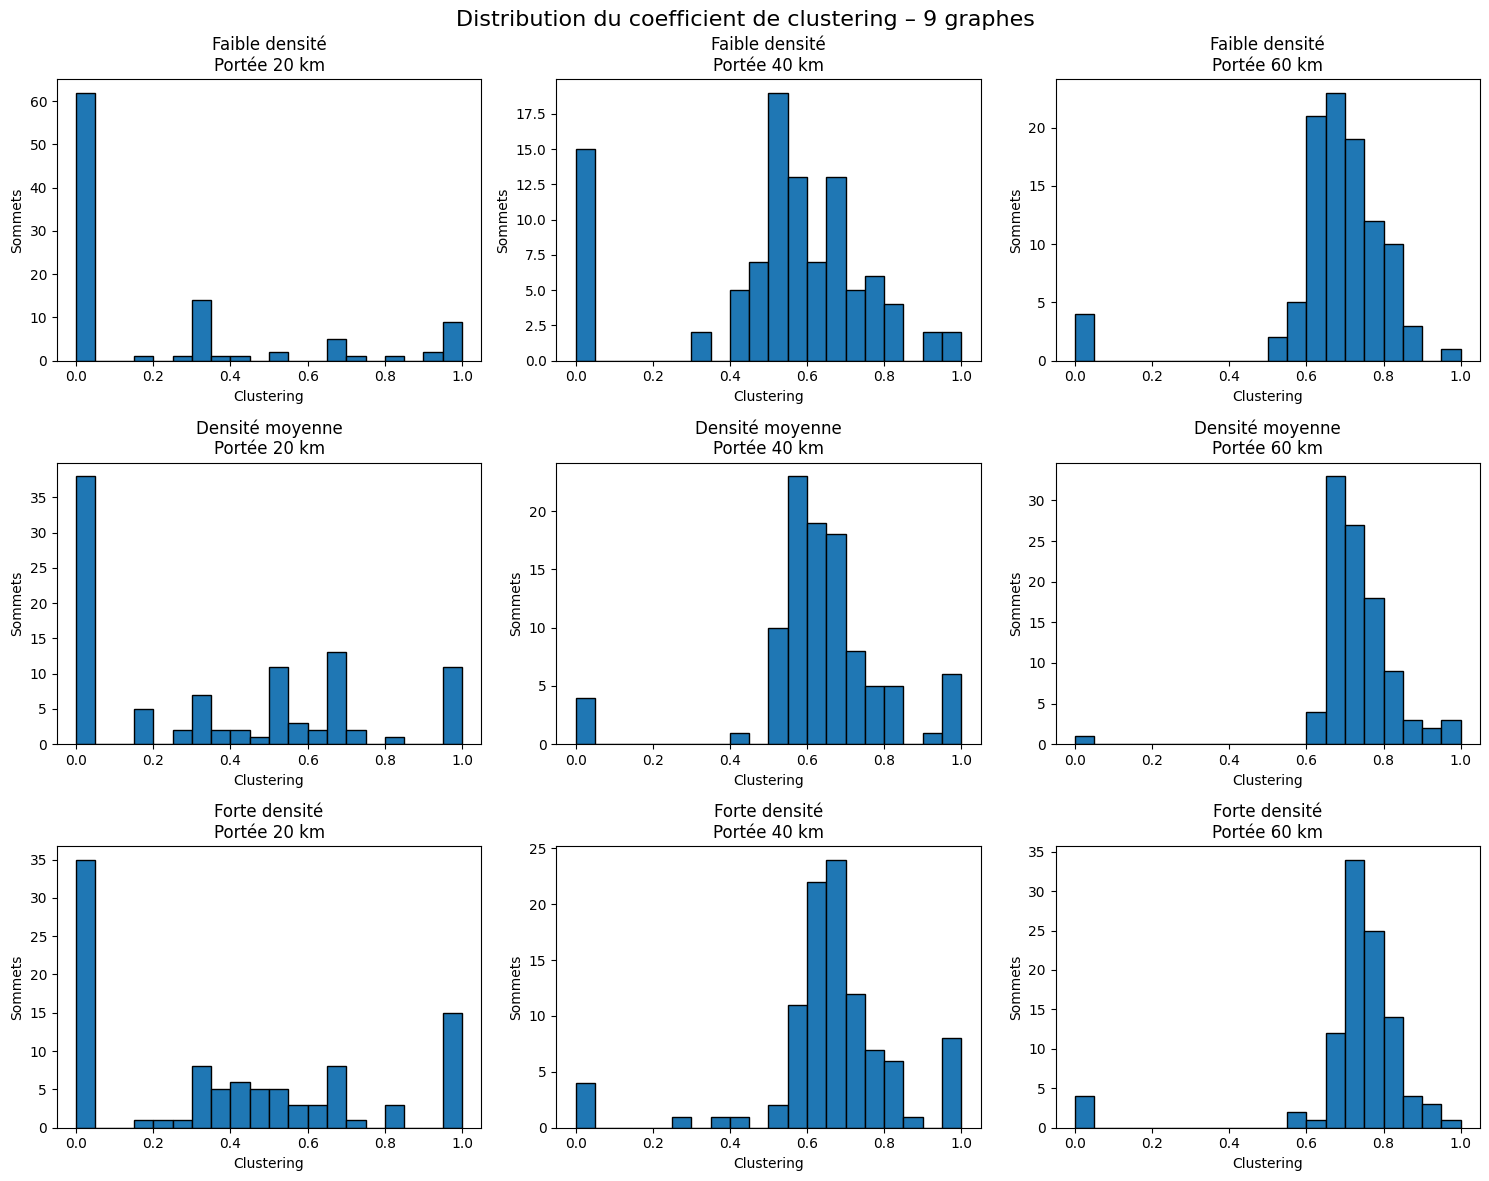

In [21]:
def plot_all_clustering_distributions(results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    portees = [20, 40, 60]

    for i, (label, data) in enumerate(results.items()):
        for j, portee in enumerate(portees):
            ax = axes[i, j]
            clust = data[portee]["clustering"]

            ax.hist(clust, bins=np.arange(0, 1.05, 0.05), edgecolor='black')
            ax.set_title(f"{label}\nPortée {portee} km")
            ax.set_xlabel("Clustering")
            ax.set_ylabel("Sommets")

    fig.suptitle("Distribution du coefficient de clustering – 9 graphes", fontsize=16)
    plt.tight_layout()
    plt.show()
plot_all_clustering_distributions(analyze_all())

### Nombre de cliques

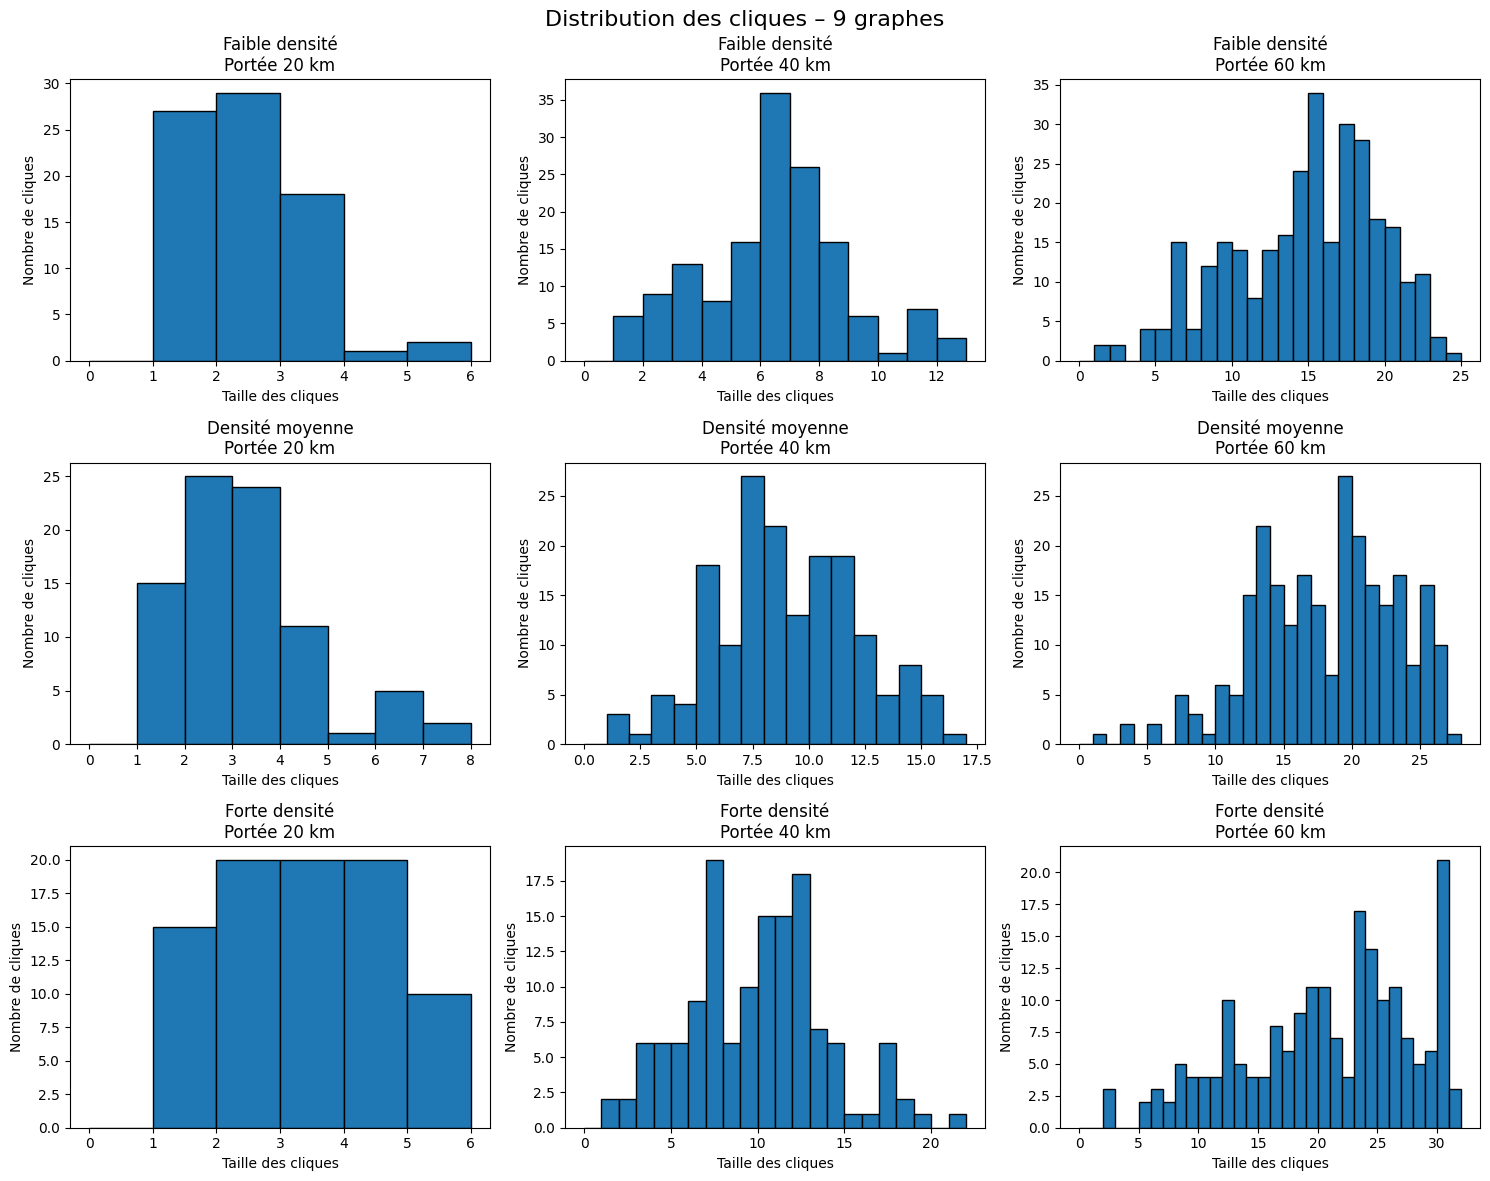

In [22]:
def plot_all_cliques(results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    portees = [20, 40, 60]

    for i, (label, data) in enumerate(results.items()):
        for j, portee in enumerate(portees):
            ax = axes[i, j]
            cliques = data[portee]["cliques"]

            if len(cliques) > 0:
                ax.hist(cliques, bins=range(max(cliques)+2), edgecolor='black')
            ax.set_title(f"{label}\nPortée {portee} km")
            ax.set_xlabel("Taille des cliques")
            ax.set_ylabel("Nombre de cliques")

    fig.suptitle("Distribution des cliques – 9 graphes", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_all_cliques(analyze_all())

### Nombre de composantes connexes

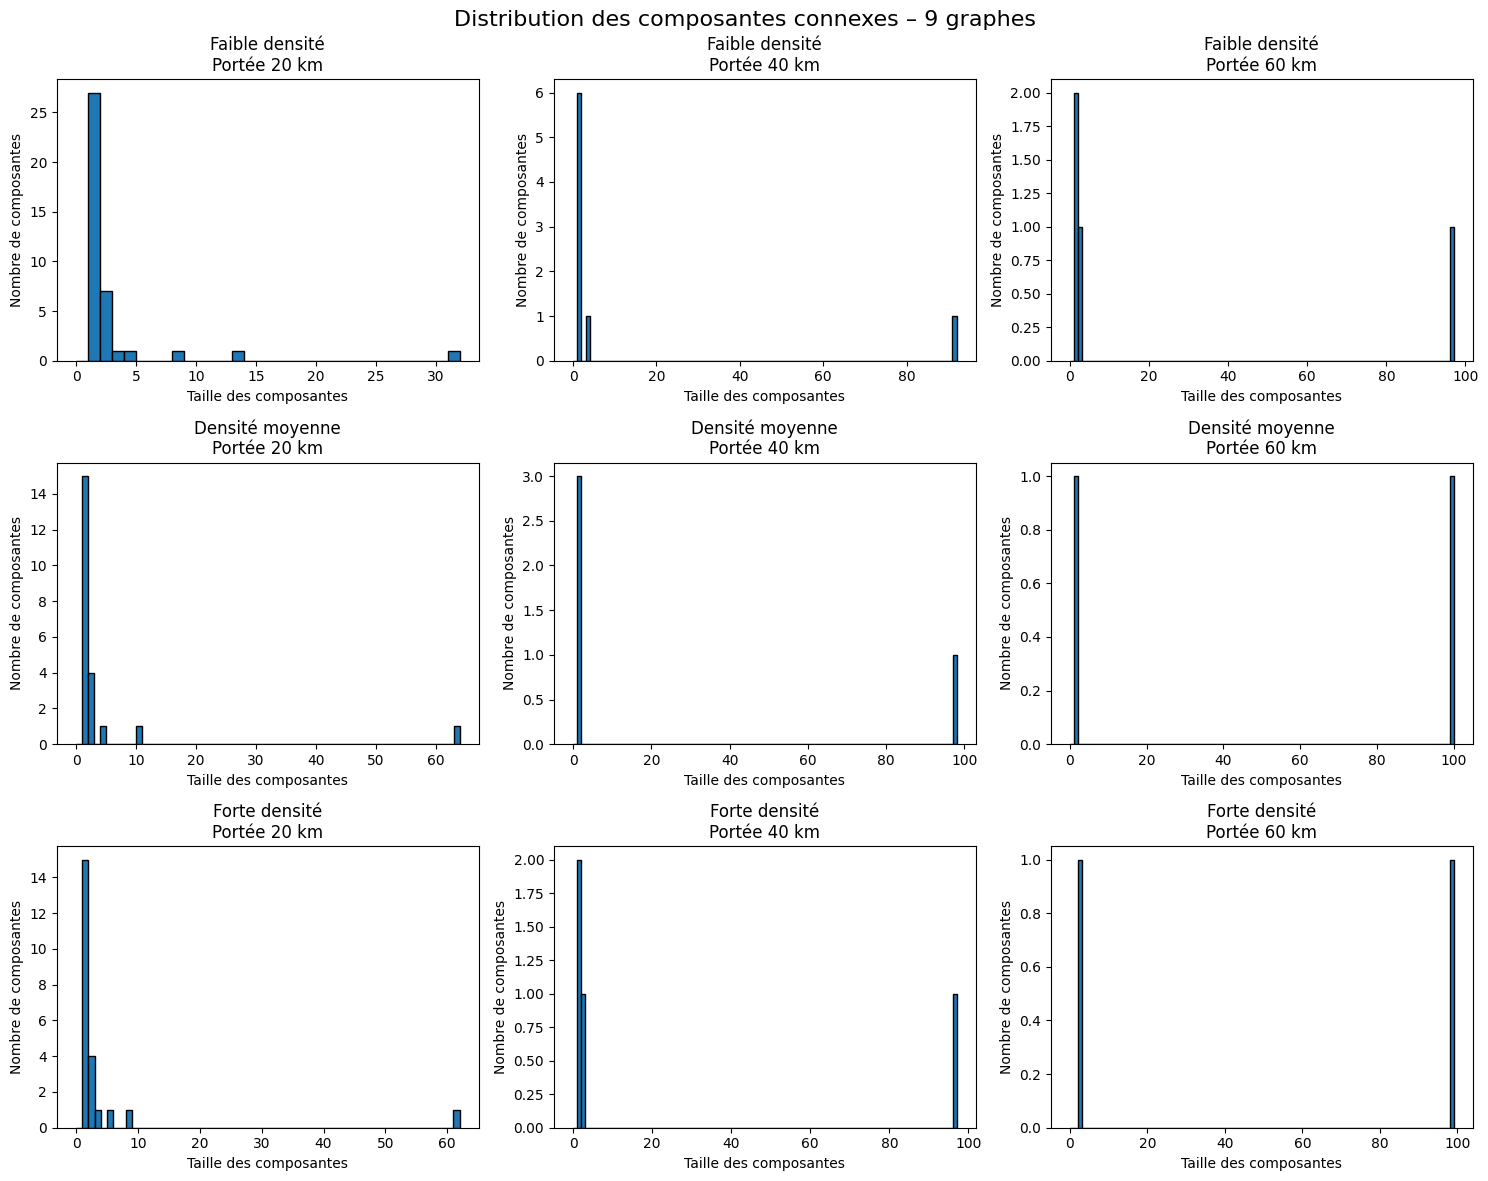

In [23]:
def plot_all_components(results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    portees = [20, 40, 60]

    for i, (label, data) in enumerate(results.items()):
        for j, portee in enumerate(portees):
            ax = axes[i, j]
            comps = data[portee]["components"]

            ax.hist(comps, bins=range(max(comps)+2), edgecolor='black')
            ax.set_title(f"{label}\nPortée {portee} km")
            ax.set_xlabel("Taille des composantes")
            ax.set_ylabel("Nombre de composantes")

    fig.suptitle("Distribution des composantes connexes – 9 graphes", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_all_components(analyze_all())

### Plus courts chemins (en nombre de sauts)

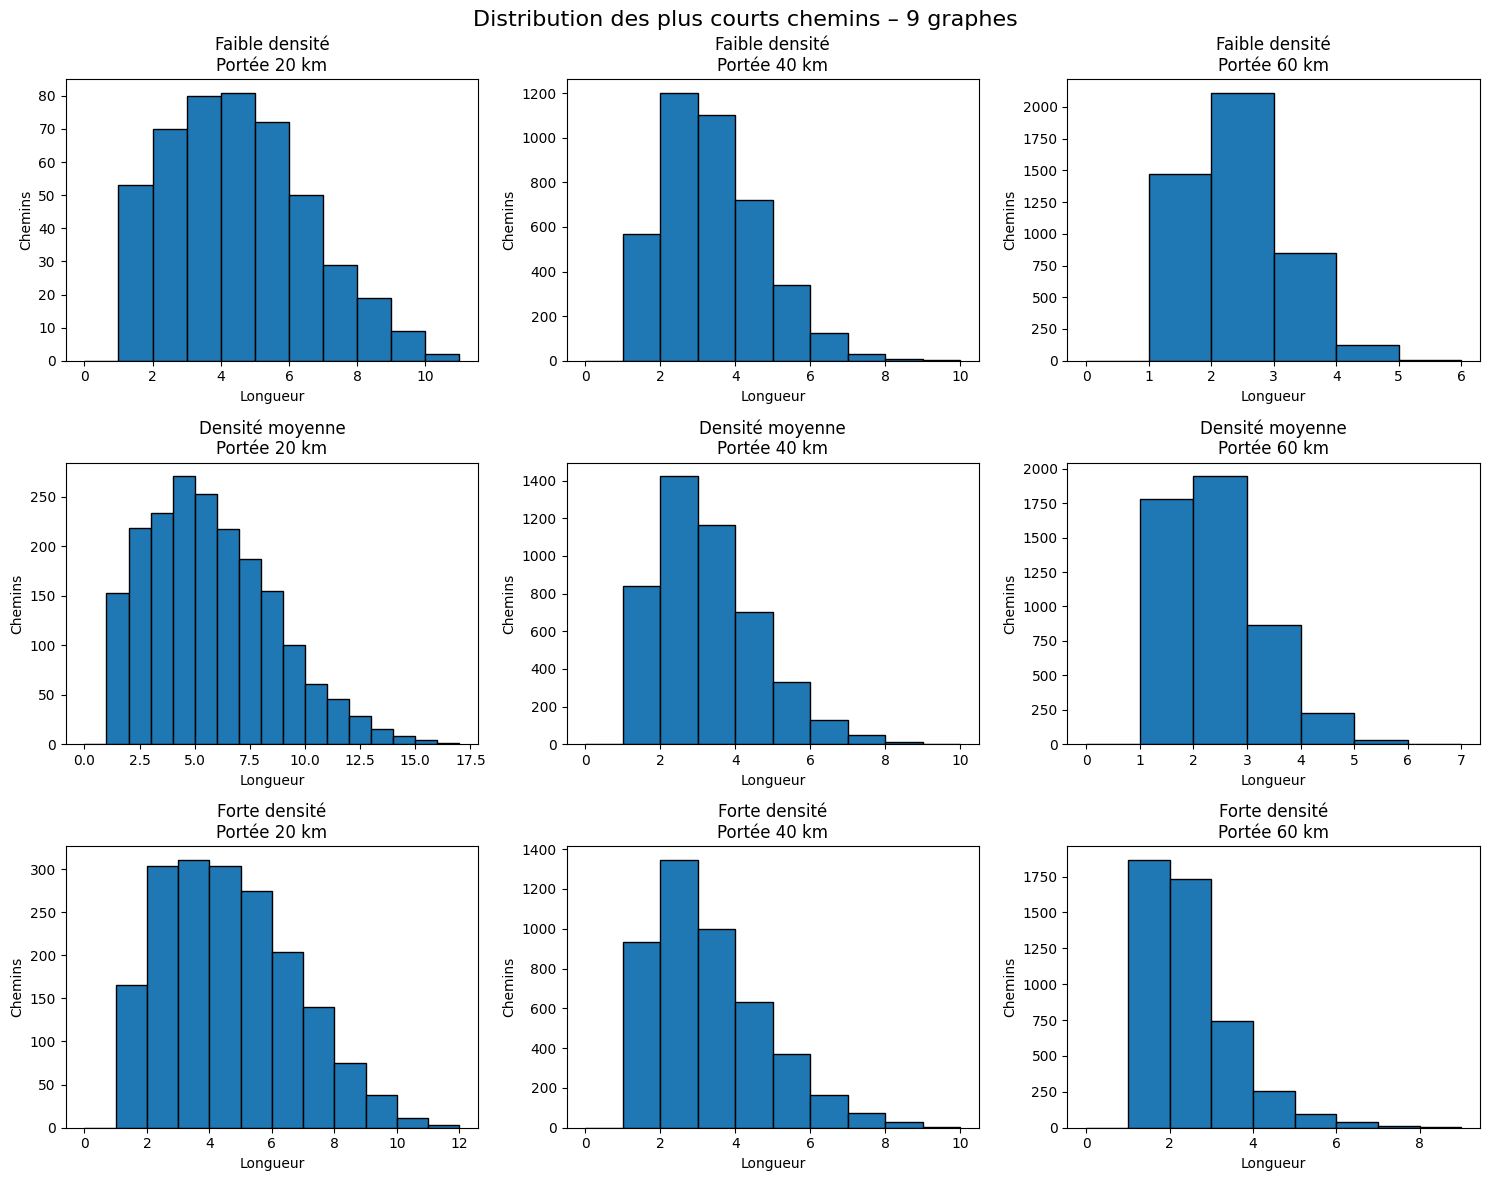

In [24]:
def plot_all_shortest_paths(results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    portees = [20, 40, 60]

    for i, (label, data) in enumerate(results.items()):
        for j, portee in enumerate(portees):
            ax = axes[i, j]
            dist = data[portee]["dist"]

            ax.hist(dist, bins=range(max(dist)+2), edgecolor='black')
            ax.set_title(f"{label}\nPortée {portee} km")
            ax.set_xlabel("Longueur")
            ax.set_ylabel("Chemins")

    fig.suptitle("Distribution des plus courts chemins – 9 graphes", fontsize=16)
    plt.tight_layout()
    plt.show()
plot_all_shortest_paths(analyze_all())

In [29]:
def print_bilan(results):
    """
    Affiche un bilan synthétique des 9 graphes
    à partir des résultats de analyze_all()
    """

    print("\n - BILAN DES 9 GRAPHES - \n")

    for label, data in results.items():

        print(f"\n {label.upper()} ")

        for portee, metrics in data.items():

            deg = metrics["degree"]
            clust = metrics["clustering"]
            comps = metrics["components"]
            dist = metrics["dist"]
            cliques = metrics["cliques"]

            degree_mean = sum(deg) / len(deg)
            clustering_mean = sum(clust) / len(clust)
            nb_components = len(comps)
            nb_cliques = len(cliques)
            avg_shortest_path = sum(dist) / len(dist) if len(dist) > 0 else float("inf")

            print(f"\nPortée = {portee} km")
            print(f"  Degré moyen              : {degree_mean:.3f}")
            print(f"  Clustering moyen         : {clustering_mean:.3f}")
            print(f"  Nombre de cliques        : {nb_cliques}")
            print(f"  Ordres des cliques       : {cliques}")
            print(f"  Nombre de composantes    : {nb_components}")
            print(f"  Ordres des composantes   : {comps}")
            print(f"  Distance moyenne         : {avg_shortest_path:.3f}")

print_bilan(analyze_all())


 - BILAN DES 9 GRAPHES - 


 FAIBLE DENSITÉ 

Portée = 20 km
  Degré moyen              : 1.800
  Clustering moyen         : 0.226
  Nombre de cliques        : 77
  Ordres des cliques       : [1, 1, 1, 2, 2, 2, 2, 3, 2, 3, 3, 3, 1, 2, 2, 1, 2, 2, 3, 3, 5, 4, 5, 3, 1, 1, 3, 2, 3, 1, 2, 1, 2, 3, 1, 2, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 1, 1, 1, 3, 2, 1, 1, 3, 2, 2, 2, 1, 3, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1]
  Nombre de composantes    : 39
  Ordres des composantes   : [1, 13, 31, 1, 1, 2, 4, 3, 2, 1, 8, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]
  Distance moyenne         : 4.028

Portée = 40 km
  Degré moyen              : 11.420
  Clustering moyen         : 0.520
  Nombre de cliques        : 147
  Ordres des cliques       : [1, 3, 4, 5, 5, 5, 2, 2, 4, 4, 7, 7, 4, 5, 2, 1, 7, 5, 4, 4, 7, 5, 5, 6, 6, 6, 6, 1, 3, 3, 3, 3, 6, 6, 5, 6, 6, 6, 6, 5, 5, 2, 2, 3, 3, 4, 4, 6, 6, 6, 3, 3, 6, 7, 7, 7, 6, 6, 2, 6, 8, 7, 11, 12, 11, 9, 12, 8, 8

## Partie 3 (étude des graphes valués) : 
Reprendre les questions précédentes pour une portée de 60Km. Le coût associé à chaque arête est égal au carré de la distance entre les deux nanosatellites en extrémités.

In [ ]:
def analyser_graphe_value(G):
    """
    Analyse un graphe pondéré et retourne les métriques clés.
    """
    stats = {}
    
    #  Degré classique et Force
    degrees = dict(G.degree())
    strengths = dict(G.degree(weight='weight'))
    stats['avg_degree'] = np.mean(list(degrees.values()))
    stats['avg_strength'] = np.mean(list(strengths.values()))
    
    # Clustering pondéré
    clustering_w = nx.clustering(G, weight='weight')
    stats['avg_clustering_weighted'] = np.mean(list(clustering_w.values()))
    
    # Composantes connexes 
    components = list(nx.connected_components(G))
    stats['nb_components'] = len(components)
    stats['largest_cc_size'] = len(max(components, key=len))
    # Chemins les plus courts ( Dijkstra)
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    
    # Calcul de toutes les distances minimales pondérées
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(G_sub, weight='weight'))
    
    all_weighted_distances = []
    for source in path_lengths:
        for target in path_lengths[source]:
            if source < target:
                all_weighted_distances.append(path_lengths[source][target])
                
    stats['avg_weighted_path'] = np.mean(all_weighted_distances)
    stats['weighted_distances'] = all_weighted_distances
    
    return stats



portee_p3 = 60
nom_dossier = "Topologies-20260107"

fichiers = {
    "Faible densité": f"{nom_dossier}/topology_low.csv",
    "Densité moyenne": f"{nom_dossier}/topology_avg.csv",
    "Forte densité": f"{nom_dossier}/topology_high.csv"
}

resultats_p3 = {}

for label, path in fichiers.items():
    print(f"Analyse de la configuration : {label}...")
    ligne = load_topology(path)
    positions, M, ids = get_positions_and_matrix(ligne)
    
    # On utilise weighted=True ici
    G_val = create_graph(positions, M, ids, portee_p3, weighted=True)
    
    res = analyser_graphe_value(G_val)
    resultats_p3[label] = res
    print(f"  - Coût moyen du chemin (Dijkstra): {res['avg_weighted_path']:.2f}")
    print(f"  - Force moyenne des nœuds (Strength): {res['avg_strength']:.2f}")
    print(f"  - Clustering pondéré moyen: {res['avg_clustering_weighted']:.4f}")
    print("-" * 30)

Analyse de la configuration : Faible densité...
  - Coût moyen du chemin (Dijkstra): 2458.22
  - Force moyenne des nœuds (Strength): 56724.77
  - Clustering pondéré moyen: 0.2988
------------------------------
Analyse de la configuration : Densité moyenne...
  - Coût moyen du chemin (Dijkstra): 1946.17
  - Force moyenne des nœuds (Strength): 62514.11
  - Clustering pondéré moyen: 0.2792
------------------------------
Analyse de la configuration : Forte densité...
  - Coût moyen du chemin (Dijkstra): 2181.65
  - Force moyenne des nœuds (Strength): 62621.12
  - Clustering pondéré moyen: 0.2686
------------------------------


Génération des graphiques pour : Faible densité


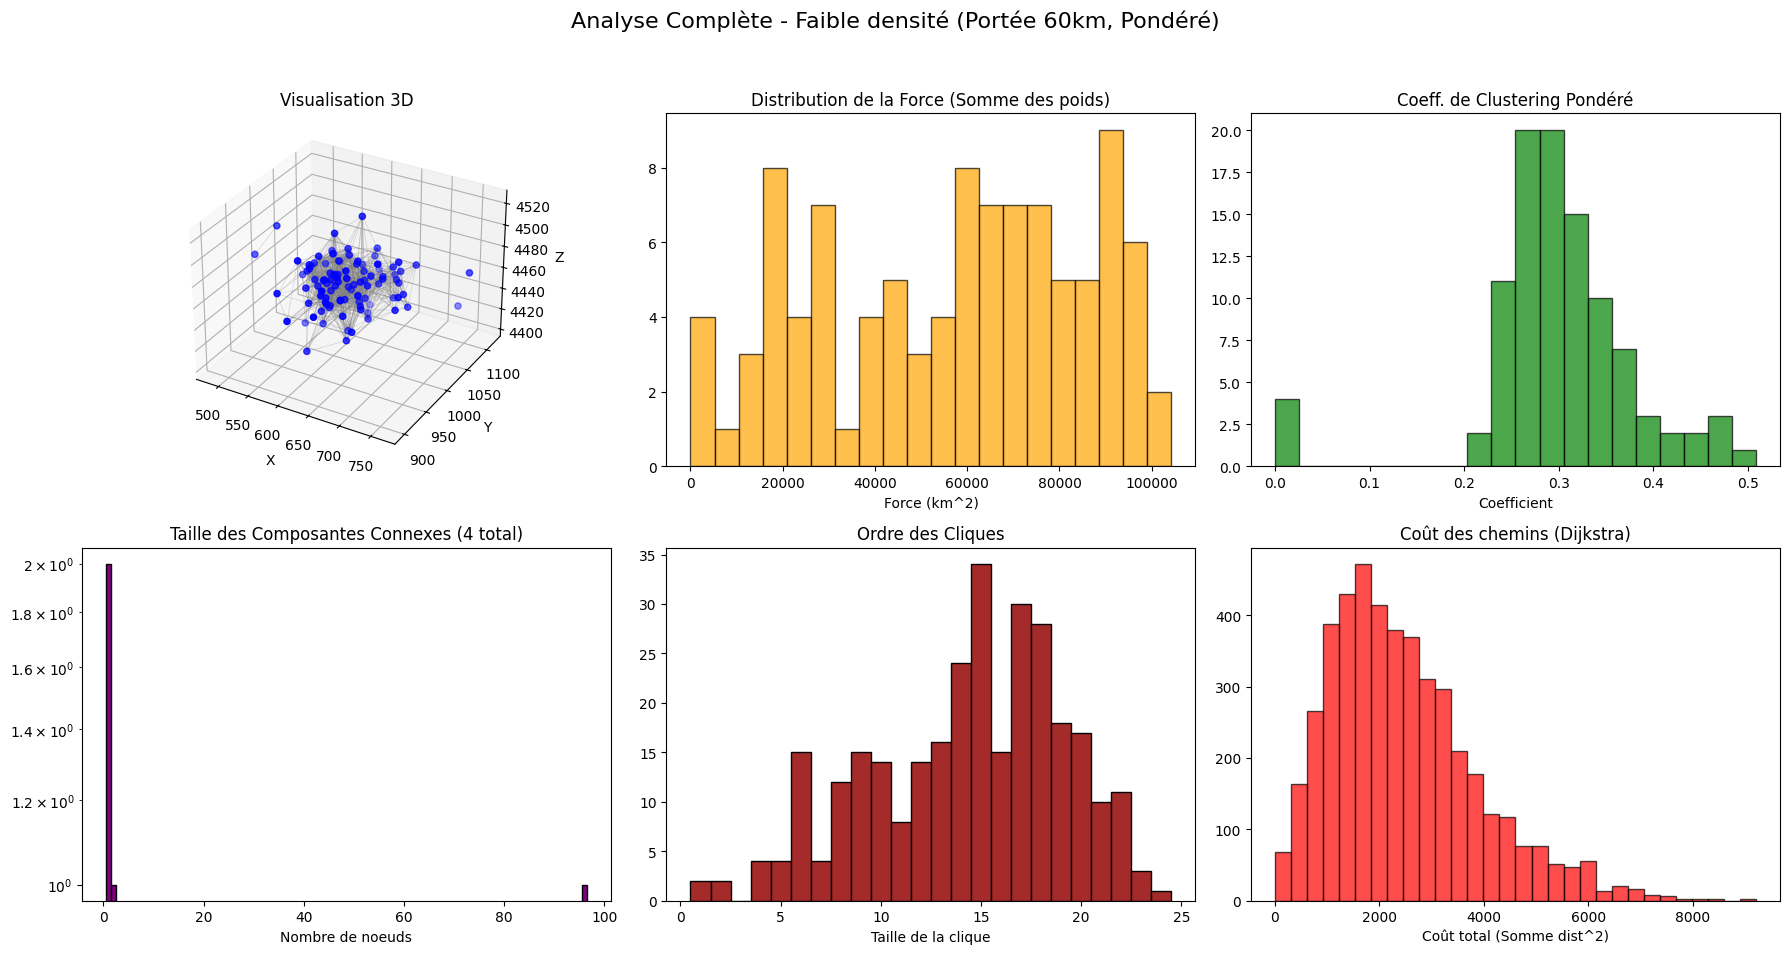

Génération des graphiques pour : Densité moyenne


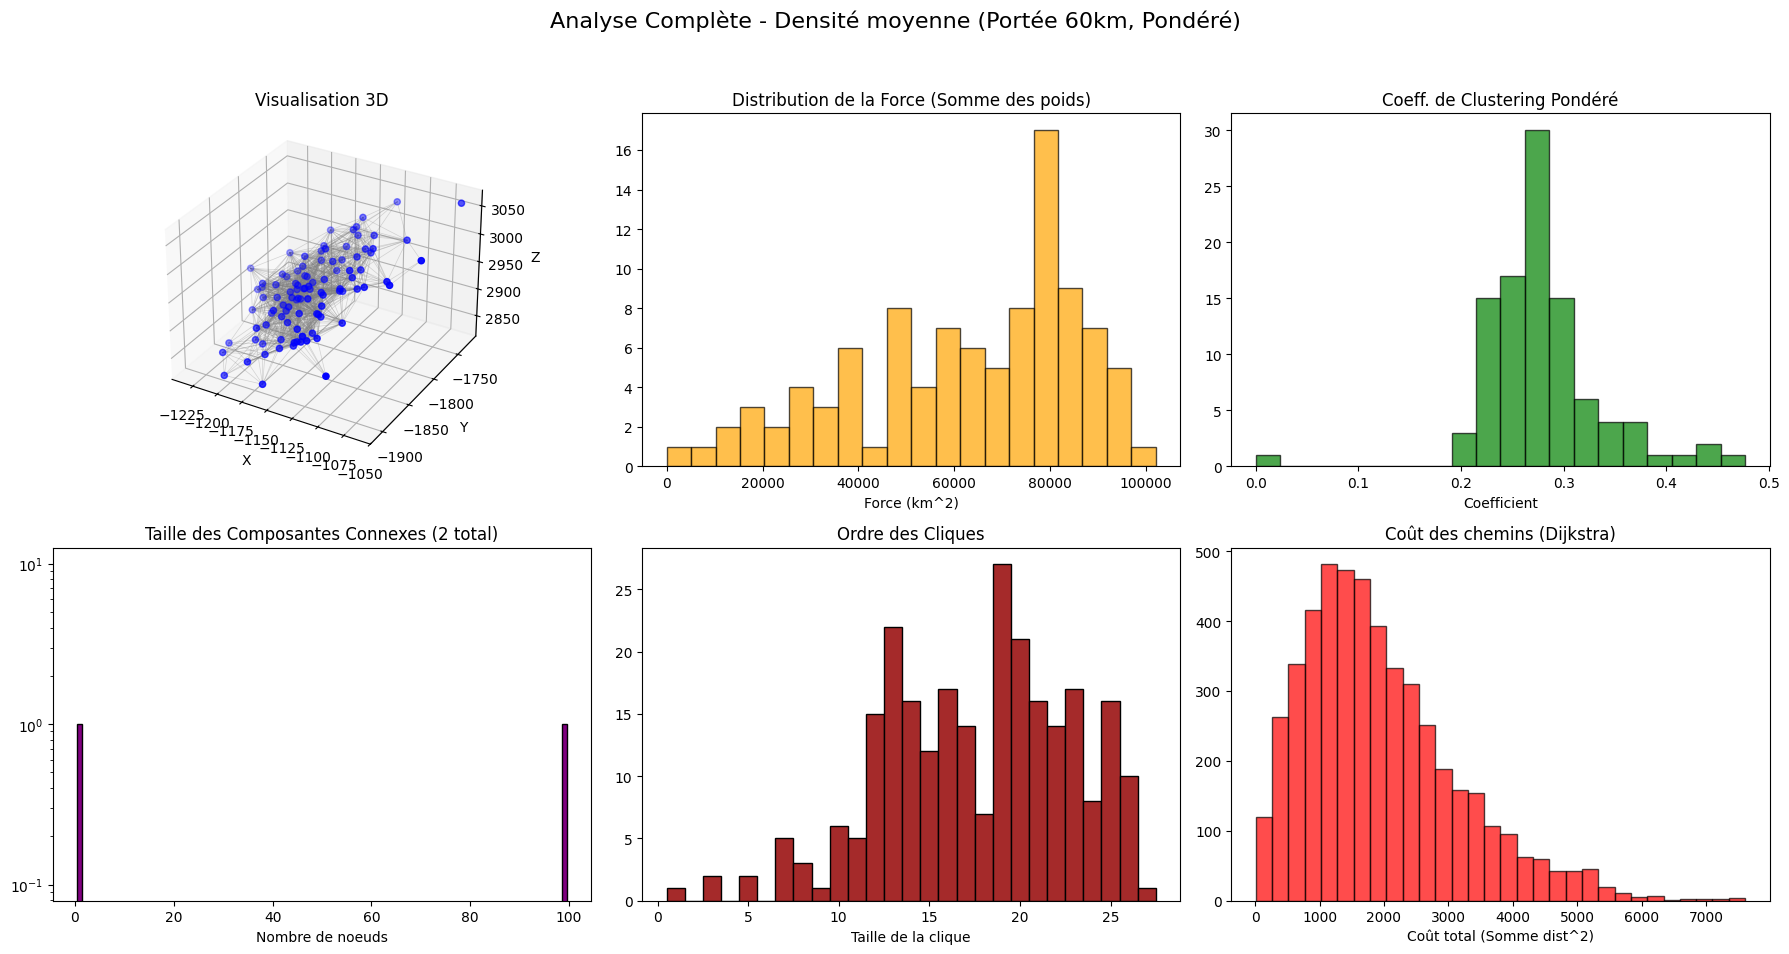

Génération des graphiques pour : Forte densité


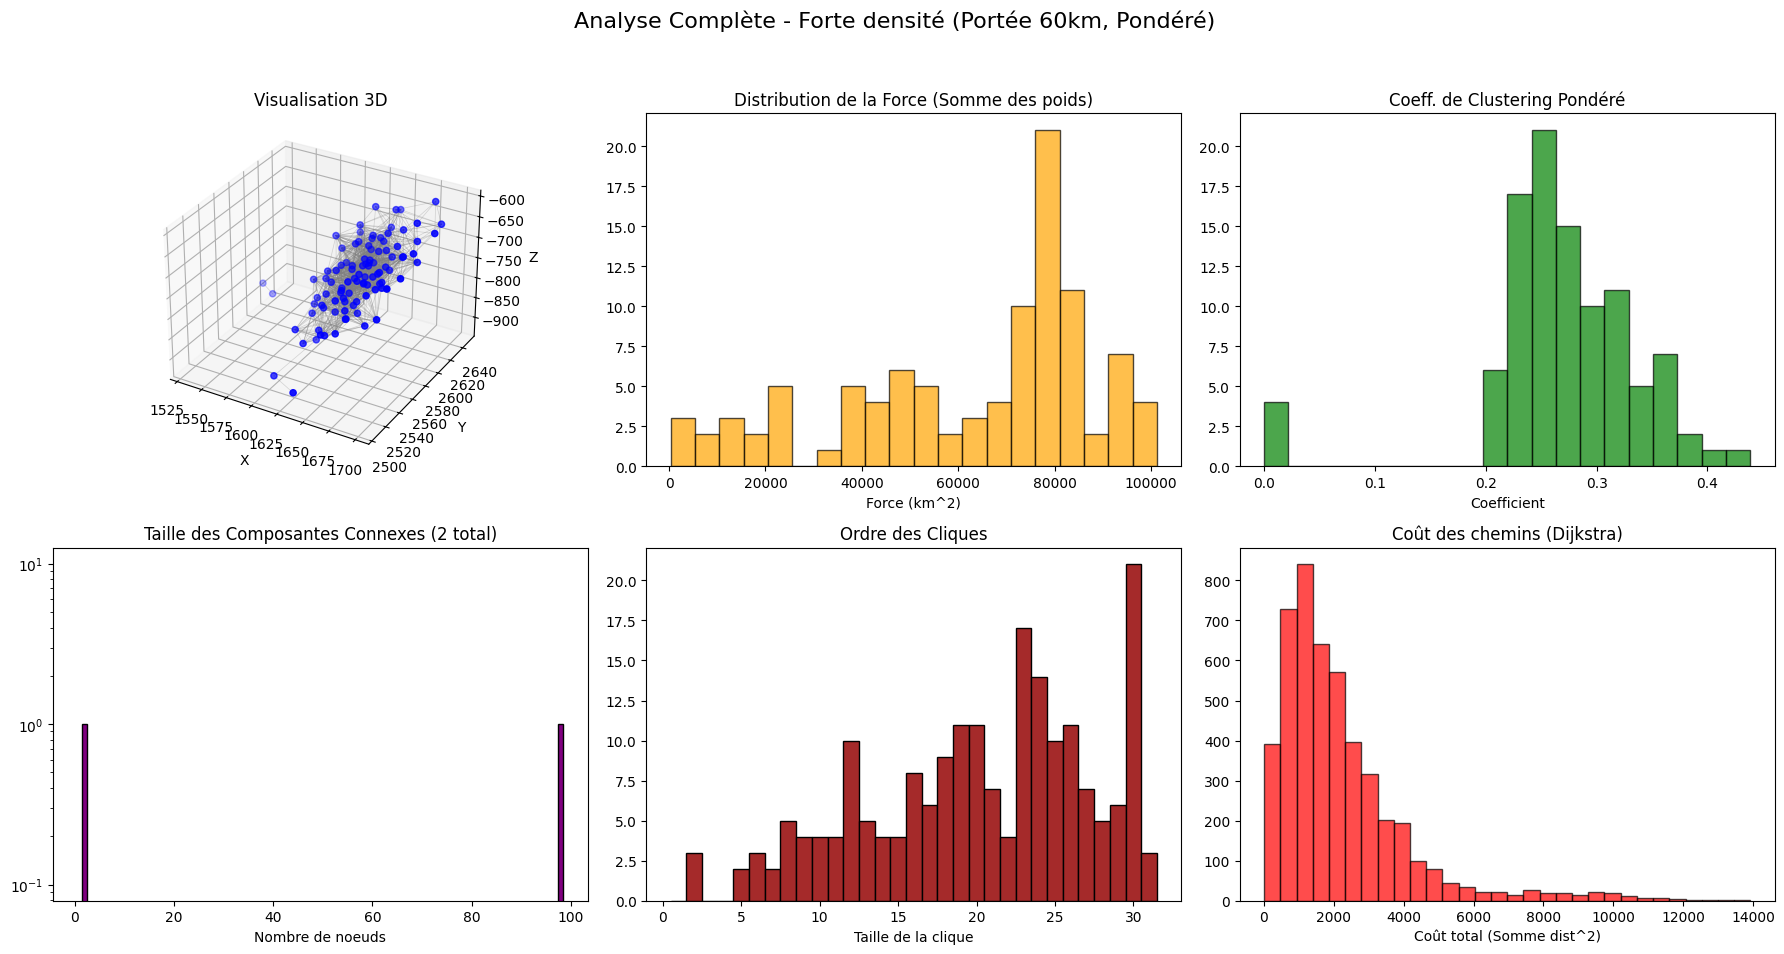

In [31]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def get_weighted_metrics_distributions(G):
    """
    Calcule toutes les distributions pour le graphe pondéré.
    """
    data = {}
    
    # La Force et le degré simple 
    data['strengths'] = [s for n, s in G.degree(weight='weight')]
    
    # Clustering Pondéré
    data['clustering'] = list(nx.clustering(G, weight='weight').values())
    
    # Cliques et Composantes connexes
    cliques = list(nx.find_cliques(G))
    data['clique_orders'] = [len(c) for c in cliques]
    
    components = list(nx.connected_components(G))
    data['component_orders'] = [len(c) for c in components]
    
    # Chemins les plus courts (Dijkstra)
    path_costs = []
    for C in components:
        if len(C) > 1:
            sub = G.subgraph(C)
            lengths = nx.all_pairs_dijkstra_path_length(sub, weight='weight')
            for src, targets in lengths:
                for tgt, cost in targets.items():
                    if src < tgt:
                        path_costs.append(cost)
    data['path_costs'] = path_costs
    
    return data


def visualize_part3_complete(label, G, positions, portee):
    """
    Affiche le Graphe 3D et 4 histogrammes pour la Partie 3.
    """
    metrics = get_weighted_metrics_distributions(G)

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"Analyse Complète - {label} (Portée {portee}km, Pondéré)", fontsize=16)


    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    xs = [positions[n][0] for n in G.nodes()]
    ys = [positions[n][1] for n in G.nodes()]
    zs = [positions[n][2] for n in G.nodes()]
    ax1.scatter(xs, ys, zs, c='blue', s=20)
    
 
    if len(G.edges()) < 2000: 
        for u, v in G.edges():
            x = [positions[u][0], positions[v][0]]
            y = [positions[u][1], positions[v][1]]
            z = [positions[u][2], positions[v][2]]
            ax1.plot(x, y, z, c='gray', alpha=0.3, linewidth=0.5)
            
    ax1.set_title("Visualisation 3D")
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.hist(metrics['strengths'], bins=20, color='orange', edgecolor='black', alpha=0.7)
    ax2.set_title("Distribution de la Force (Somme des poids)")
    ax2.set_xlabel("Force (km^2)")
    
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.hist(metrics['clustering'], bins=20, color='green', edgecolor='black', alpha=0.7)
    ax3.set_title("Coeff. de Clustering Pondéré")
    ax3.set_xlabel("Coefficient")

    ax4 = fig.add_subplot(2, 3, 4)
    if metrics['component_orders']:
        ax4.hist(metrics['component_orders'], bins=range(1, max(metrics['component_orders'])+2), color='purple', edgecolor='black', align='left')
    ax4.set_title(f"Taille des Composantes Connexes ({len(metrics['component_orders'])} total)")
    ax4.set_xlabel("Nombre de noeuds")
    ax4.set_yscale('log') # Log scale 

    ax5 = fig.add_subplot(2, 3, 5)
    if metrics['clique_orders']:
        ax5.hist(metrics['clique_orders'], bins=range(1, max(metrics['clique_orders'])+2), color='brown', edgecolor='black', align='left')
    ax5.set_title("Ordre des Cliques")
    ax5.set_xlabel("Taille de la clique")

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.hist(metrics['path_costs'], bins=30, color='red', edgecolor='black', alpha=0.7)
    ax6.set_title("Coût des chemins (Dijkstra)")
    ax6.set_xlabel("Coût total (Somme dist^2)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


nom_dossier = "Topologies-20260107"
fichiers = {
    "Faible densité": f"{nom_dossier}/topology_low.csv",
    "Densité moyenne": f"{nom_dossier}/topology_avg.csv",
    "Forte densité": f"{nom_dossier}/topology_high.csv"
}

portee_p3 = 60

for label, fichier in fichiers.items():
    print(f"Génération des graphiques pour : {label}")
   
    ligne = load_topology(fichier)
    positions, M, ids = get_positions_and_matrix(ligne)
    G = create_graph(positions, M, ids, portee_p3, weighted=True)
    visualize_part3_complete(label, G, positions, portee_p3)

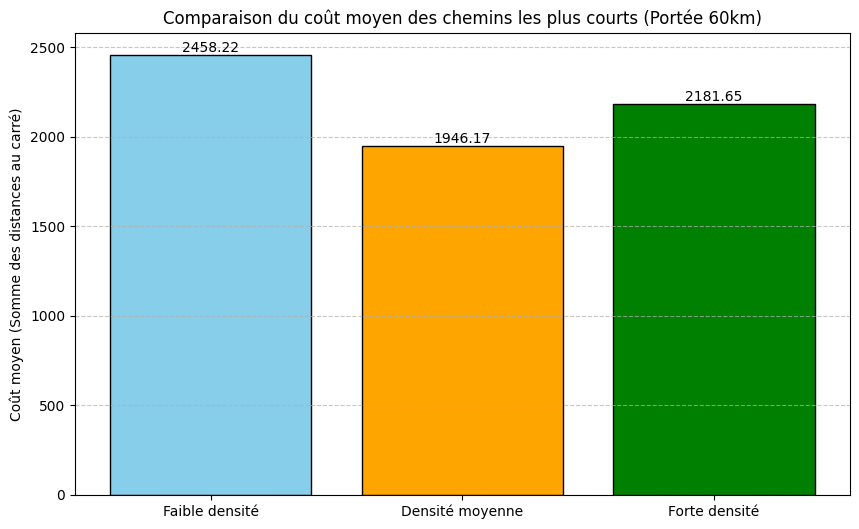

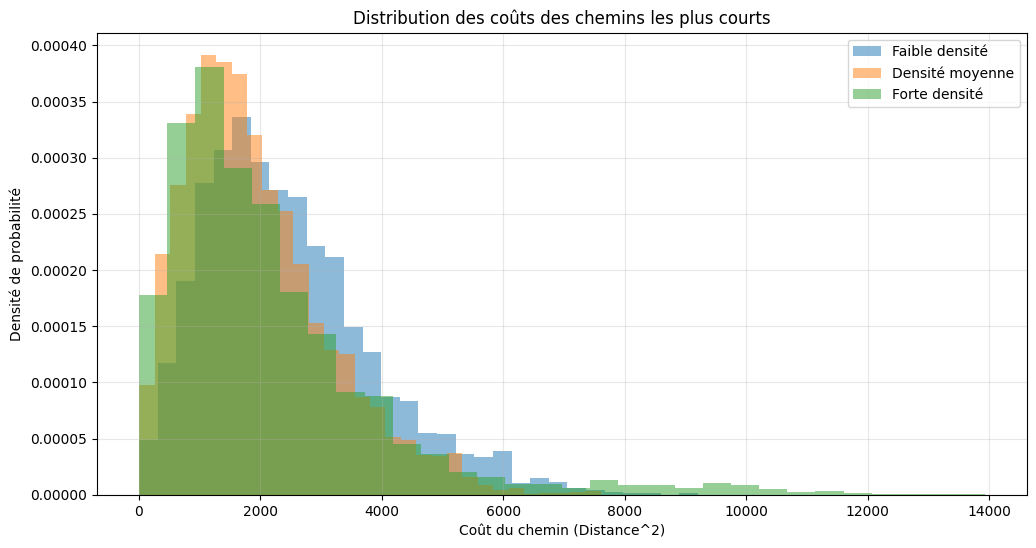

In [28]:
import matplotlib.pyplot as plt

def plot_comparaison_valutee(resultats_p3):
    """
    Génère des graphiques comparatifs pour l'étude des graphes pondérés.
    """
    labels = list(resultats_p3.keys())
    couts_moyens = [resultats_p3[l]['avg_weighted_path'] for l in labels]
    strengths_moyennes = [resultats_p3[l]['avg_strength'] for l in labels]

    #  Coût moyen des chemins
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, couts_moyens, color=['skyblue', 'orange', 'green'], edgecolor='black')
    plt.ylabel("Coût moyen (Somme des distances au carré)")
    plt.title("Comparaison du coût moyen des chemins les plus courts (Portée 60km)")
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    plt.figure(figsize=(12, 6))
    for label in labels:
        plt.hist(resultats_p3[label]['weighted_distances'], bins=30, alpha=0.5, label=label, density=True)
    
    plt.xlabel("Coût du chemin (Distance^2)")
    plt.ylabel("Densité de probabilité")
    plt.title("Distribution des coûts des chemins les plus courts")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# comparaison
plot_comparaison_valutee(resultats_p3)